In [1]:
import sys
sys.path.append('..')
import numpy as np
import brainpy as bp
import brainpy.math as bm
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib as mpl
from CANN_DDM_model import CANN_DDM_model
from scipy.interpolate import interp1d

from tqdm import tqdm
import pickle
import seaborn as sns
import json


/projectnb/ecog-eeg/cyw6/.conda/envs/cann_ddm_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('../results/model_config_default.json') as data:
    CANN_params = json.load(data)
    decision_space_params = CANN_params['decision_space_params']
    edge_pop = CANN_params['edge_pop']
    bump_pop = CANN_params['bump_pop']




In [3]:

pos_offset = 0.003
model = CANN_DDM_model(CANN_params = CANN_params)

In [4]:
t_start = int(decision_space_params['t_start'])
k1 = edge_pop['k1']
k2 = edge_pop['k2']
K0 = edge_pop['k0']

# Aggregate over multiple runs and compute per-bin per-neuron mean firing rates
x_list = []
r_E_list = []
r_B_list = []
num_runs = 30
np.random.seed(2025)
for i in range(num_runs):
    drift_rate = np.random.uniform(-1, 1)
    decision_space_params.update({'seed': 2025, 'drift_rate': drift_rate})
    CANN_params.update({'decision_space_params': decision_space_params})
    model = CANN_DDM_model(CANN_params=CANN_params)
    mon_vars = ['theta_B', 'theta_E', 'hit_boundary', 'x_B', 'x_E', 'c_BE_dyn', 'r_E', 'r_B']
    runner, RT = model.run_simulation(mon_vars=mon_vars, progress_bar=False, pos_offset=pos_offset, get_RT=True)

    if not RT:
        continue
    else:
        t_end = int(t_start + RT)
        # x_E: (T,)
        x_E = runner.mon.x_E[t_start:t_end, 0]
        # r_E: (T, N)
        r_E = runner.mon.r_E[t_start:t_end, k1:k2]
        r_B = runner.mon.r_B[t_start:t_end, k1:k2]
        x_list.append(x_E)
        r_E_list.append(r_E)
        r_B_list.append(r_B)



In [5]:
# Vectorized binning and averaging across all runs
if len(x_list) == 0:
    fr_E_per_x = np.empty((0, 0))
    fr_B_per_x = np.empty((0, 0))
    bin_centers = np.array([])
else:
    x_all = np.concatenate(x_list, axis=0).reshape(-1)
    r_E_all = np.concatenate(r_E_list, axis=0)  # (T_total, N)
    r_B_all = np.concatenate(r_B_list, axis=0)  # (T_total, N)

    # Bin settings
    num_bins = 50
    bin_edges = np.linspace(0.05, 1, num_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Assign each time point to a bin (clip to [0,1])
    x_all = np.clip(x_all, 0.0, 1.0)
    bin_idx = np.digitize(x_all, bin_edges, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, num_bins - 1)

    # One-hot for bins: (T_total, num_bins)
    M_E = (bin_idx[:, None] == np.arange(num_bins)[None, :]).astype(r_E_all.dtype)
    M_B = (bin_idx[:, None] == np.arange(num_bins)[None, :]).astype(r_B_all.dtype)

    # Sum per bin per neuron: (num_bins, N)
    sums_E = M_E.T @ r_E_all
    sums_B = M_B.T @ r_B_all
    counts_E = M_E.sum(axis=0)  # (num_bins,)
    counts_B = M_B.sum(axis=0)  # (num_bins,)

    # Mean with zero-count handling
    with np.errstate(invalid='ignore', divide='ignore'):
        fr_E_per_x = sums_E / counts_E[:, None]
        fr_B_per_x = sums_B / counts_B[:, None]
    fr_E_per_x[counts_E == 0, :] = np.nan
    fr_B_per_x[counts_B == 0, :] = np.nan

# Results:
# - bin_centers: (num_bins,)
# - mean_rates_per_bin: (num_bins, N)
fr_E_per_x = fr_E_per_x[::-1, ::-1].T
fr_B_per_x = fr_B_per_x[::-1, ::-1].T

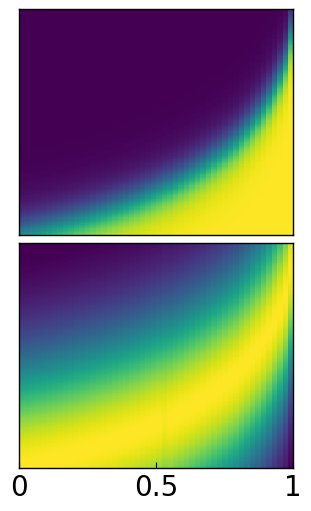

In [6]:



#Per-panel normalization
vals_E = fr_E_per_x.reshape(-1)
vals_B = fr_B_per_x.reshape(-1)
vmin_E = np.nanpercentile(vals_E, 1)
vmax_E = np.nanpercentile(vals_E, 99)
vmin_B = np.nanpercentile(vals_B, 1)
vmax_B = np.nanpercentile(vals_B, 99)
norm_E = matplotlib.colors.Normalize(vmin=vmin_E, vmax=vmax_E)
norm_B = matplotlib.colors.Normalize(vmin=vmin_B, vmax=vmax_B)
cmap = 'viridis'

# Figure with adjusted size for square heatmaps
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(3, 5), constrained_layout=True)

# Compute extents to map x to latent variable and y to neuron indices
x_min, x_max = float(np.nanmin(bin_centers)), float(np.nanmax(bin_centers))
y_min, y_max = k1, k2 - 1

# Left subplot (Edge) - Proper aspect ratio
im1 = ax1.imshow(
    fr_E_per_x,
    aspect='auto',
    cmap=cmap,
    norm=norm_E,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    interpolation='nearest'
)
#ax1.set_title('Edge population', fontsize=20, pad=15)
#ax1.set_xlabel(r'Decision variable, $x$', fontsize=16, labelpad=2)
#ax1.set_ylabel('R-pref. Neurons', fontsize=16)
ax1.set_xticks([])
ax1.tick_params(axis='x', length=4, direction='in')
ax1.set_yticks([])
ax1.tick_params(axis='y', length=4)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# # Left subplot (Edge) - Proper aspect ratio
# im2 = ax2.imshow(
#     fr_B_per_x,
#     aspect='auto',
#     cmap=cmap,
#     norm=norm_B,
#     origin='lower',
#     extent=extent,
#     interpolation='nearest'
# )
# #ax1.set_title('Edge population', fontsize=20, pad=15)
# #ax1.set_xlabel(r'Decision variable, $x$', fontsize=16, labelpad=2)
# #ax1.set_ylabel('R-pref. Neurons', fontsize=16)
# ax2.set_xticks(x_ticks)
# ax2.set_xticklabels([])
# ax2.set_yticklabels([])
# ax2.tick_params(axis='x', length=4, direction='in')
# #ax2.invert_xaxis()
# ax2.set_xscale('log')




# Right subplot (Bump) - Proper aspect ratio
im3 = ax3.imshow(
    fr_B_per_x,
    aspect='auto',
    cmap=cmap,
    norm=norm_B,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    interpolation='nearest'
)
for spine in ax3.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_edgecolor('black')


# Set x ticks at meaningful latent values within range
x_ticks = [0.06, 0.525, 0.99]
x_tick_labels = ['0', '0.5', '1']
ax3.set_xticks(x_ticks)
ax3.set_yticklabels([])
ax3.tick_params(axis='x', length=4, direction='in')
ax3.set_xticklabels(x_tick_labels, fontsize=20)
ax3.set_yticks([])
ax3.tick_params(axis='y', length=4)

# im4 = ax4.imshow(
#     fr_E_per_x,
#     aspect='auto',
#     cmap=cmap,
#     norm=norm_B,
#     origin='lower',
#     extent=[x_min, x_max, y_min, y_max],
#     interpolation='nearest'
# )
# #ax1.set_title('Edge population', fontsize=20, pad=15)
# #ax1.set_xlabel(r'Decision variable, $x$', fontsize=16, labelpad=2)
# #ax1.set_ylabel('R-pref. Neurons', fontsize=16)
# ax4.set_xticks(x_ticks)
# ax4.set_xticklabels([])
# ax4.set_yticklabels([])
# ax4.tick_params(axis='x', length=4, direction='in')
# ax4.invert_xaxis()
# #ax4.invert_yaxis()
# ax4.set_xscale('log')

plt.show()

In [129]:
extent

[np.float64(-3.8918203185187896), np.float64(13.815510557964274), 0, 205]